In [2]:
import numpy as np
import pandas as pd
import tkinter as tk
from tkinter import filedialog
from pyFAI.test.utilstest import UtilsTest
from pyFAI.gui.jupyter import subplots, display, plot1d, plot2d
from pyFAI import load
import pyFAI
# from pyFAI.azimuthalIntegrator import AzimuthalIntegrator
from pyFAI.integrator.fiber import FiberIntegrator
from pyFAI.integrator import azimuthal
from pyFAI.units import get_unit_fiber
from pyFAI.integrator.azimuthal import AzimuthalIntegrator
from pyFAI.io.ponifile import PoniFile
import fabio
import time
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(
    {
        # 1) pick Arial for all sans-serif text…
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial"],
        # 2) make mathtext use Arial as well
        "mathtext.fontset": "custom",
        "mathtext.rm": "Arial",
        "mathtext.it": "Arial:italic",
        "mathtext.bf": "Arial:bold",
        "mathtext.default": "rm",
        # 3) still your other style settings
        "font.size": 14,
        "axes.labelsize": 22,
        "axes.titlesize": 22,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 14,
        "figure.figsize": (8, 6),
        "axes.linewidth": 3,
        "xtick.color": "white",      # tick marks white
        "ytick.color": "white",
        "xtick.labelcolor": "black", # tick labels black
        "ytick.labelcolor": "black",
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 9,
        "ytick.major.size": 9,
        "xtick.minor.size": 3,
        "ytick.minor.size": 3,
        "xtick.major.width": 1.2,
        "ytick.major.width": 1.2,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
        "axes.grid": False,
        "savefig.dpi": 300,
        # if you had usetex on, turn it off so mathtext takes over:
        "text.usetex": False,
    }
)


In [6]:
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)
root.update()
image_file = filedialog.askopenfilename(
    title="Select GIWAXS Image File",
    filetypes=[("Image files", "*.tif;*.tiff"), ("All files", "*.*")]
)
poni_file = filedialog.askopenfilename(
    title="Select Calibration File",
    filetypes=[("PONI files", "*.poni"), ("All files", "*.*")]
)
# image_savefile = filedialog.asksaveasfilename(
#     title="Save Plot As",
#     filetypes=[("PNG files", "*.png"), ("PDF files", "*.pdf"), ("All files", "*.*")]
# )
# dataframe_file = image_savefile.replace(".png", ".csv")

wavelength = 1.2398419843320025  # 10 keV in Å

In [7]:
nano_fiber_image =fabio.open(image_file).data
nano_fiber_poni = PoniFile(poni_file)


Detector Pilatus 1M	 PixelSize= 172µm, 172µm	 BottomRight (3)
Wavelength= 1.239842e-10 m
SampleDetDist= 1.908071e-01 m	PONI= 8.598813e-02, 4.399382e-02 m	rot1=-0.651412  rot2=0.022101  rot3=0.000000 rad
DirectBeamDist= 239.999 mm	Center: x=1101.580, y=530.767 pix	Tilt= 37.341° tiltPlanRotation= 2.088° 𝛌= 1.240Å


<Axes: title={'center': '2D regrouping'}, xlabel='Scattering vector $q$ ($nm^{-1}$)', ylabel='Azimuthal angle $\\chi$ ($^{o}$)'>

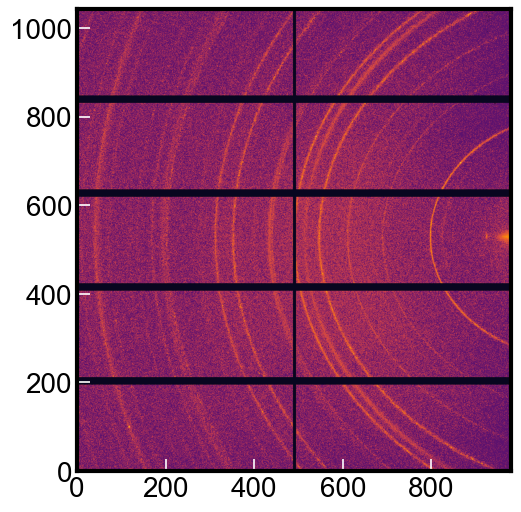

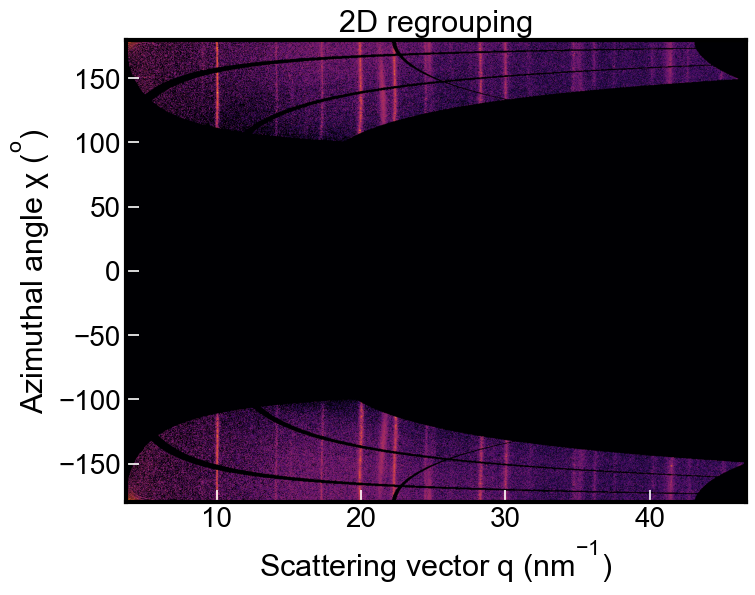

In [5]:
image = fabio.open(image_file).data

# Load the calibration file
# fi = ai.promote(type_="pyFAI.integrator.fiber.FiberIntegrator")
ai = AzimuthalIntegrator()
ai.load(poni_file)
print(ai)
# image = np.clip(image, 0, None)  # Clip the image to avoid negative values
alpha_i = 2*(2*np.pi)/360 # 2 degrees in radians
unit_qip = get_unit_fiber(name="qip_nm^-1", incident_angle=alpha_i, tilt_angle=0, sample_orientation=8) # q_r unit definition
unit_qoop = get_unit_fiber(name="qoop_nm^-1", incident_angle=alpha_i, tilt_angle=0, sample_orientation=8) # q_z

res2d = ai.integrate2d(image, 1024, 1024, method=("no", "csr", "cython")) #convert to q_r and q_z

display(image)
plot2d(res2d)


poni.poni1 0.08600942533400617
poni.poni2 0.04425118533383944


<Axes: title={'center': '2D regrouping'}, xlabel='Scattering vector $q$ ($\\AA^{-1}$)', ylabel='Azimuthal angle $\\chi$ ($^{o}$)'>

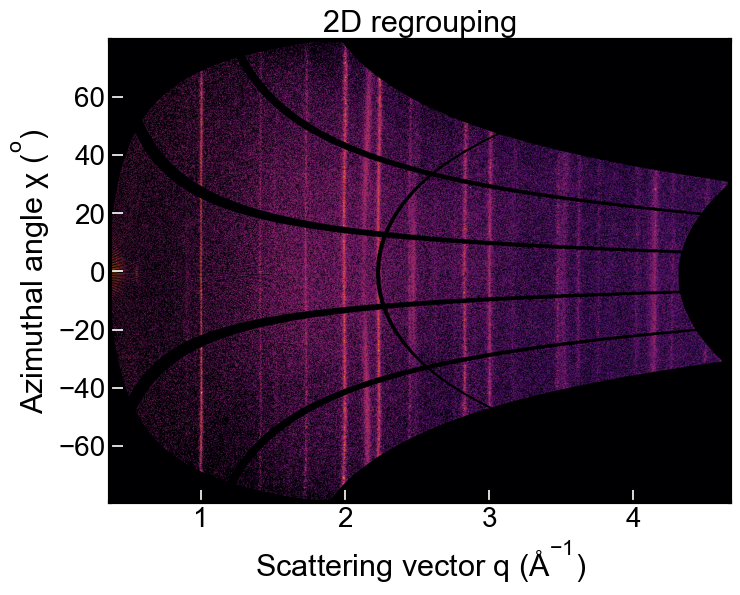

In [9]:
poni = PoniFile(data=poni_file)
pixel_to_um = 172.0
full_length = 981*pixel_to_um/1000000
print("poni.poni1", poni.poni1)
print("poni.poni2", poni.poni2)

ai2 = AzimuthalIntegrator(dist=poni.dist, poni1=poni.poni1, poni2=full_length -poni.poni2,
                     wavelength=poni.wavelength,
                     rot1=np.pi - poni.rot1, rot2=np.pi - poni.rot2, rot3=poni.rot3,
                     detector=pyFAI.detector_factory("Pilatus1M", {"orientation": 4}),
                    )
res2d2 = ai2.integrate2d(image, 1024, 1024, method=("no", "csr", "cython"), unit = "q_A^-1")
plot2d(res2d2)

c:\Users\raglo\anaconda3\envs\giwaxs_analysis_new3\Lib\site-packages\pyFAI\integrator\azimuthal.py:615: RuntimeWarning: invalid value encountered in divide
  intensity = sum_signal / sum_normalization


Text(0.5, 1.0, '')

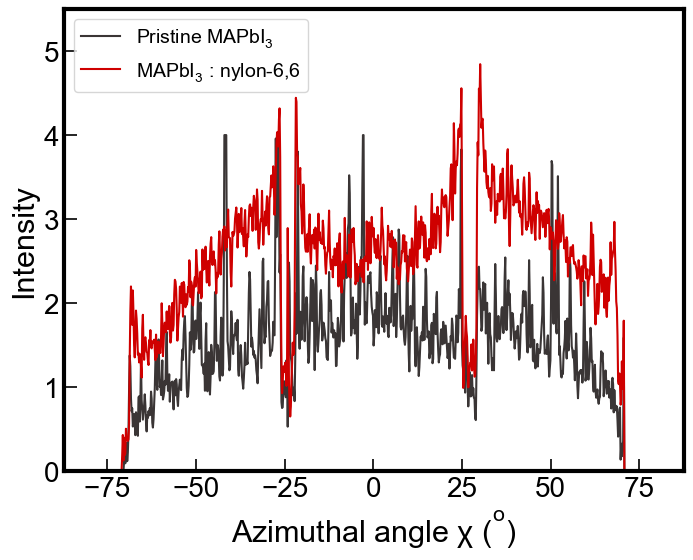

In [26]:
colors = ["#1E1919E0", "#cf0000"]
ai2 = AzimuthalIntegrator(dist=poni.dist, poni1=poni.poni1, poni2=full_length -poni.poni2,
                     wavelength=poni.wavelength,
                     rot1=np.pi - poni.rot1, rot2=np.pi - poni.rot2, rot3=poni.rot3,
                     detector=pyFAI.detector_factory("Pilatus1M", {"orientation": 4}),
                    )
res1d = ai2.integrate_radial(image, 900, radial_range=(.9, 1.1), radial_unit="q_A^-1")

ai2_nano = AzimuthalIntegrator(dist=nano_fiber_poni.dist, poni1=nano_fiber_poni.poni1, poni2=full_length -nano_fiber_poni.poni2,
                     wavelength=nano_fiber_poni.wavelength,
                     rot1=np.pi - nano_fiber_poni.rot1, rot2=np.pi - nano_fiber_poni.rot2, rot3=nano_fiber_poni.rot3,
                     detector=pyFAI.detector_factory("Pilatus1M", {"orientation": 4}),
                    )
res1d_nano = ai2_nano.integrate_radial(nano_fiber_image, 900, radial_range=(.9, 1.1), radial_unit="q_A^-1")
fig, ax = subplots()
# plot1d(res1d, ax=ax)
radial = res1d.radial
intensity = np.clip(res1d.intensity, 0, 4)
ax.plot(radial, intensity)
ax.lines[-1].set_color(colors[0])
plot1d(res1d_nano, ax=ax)
ax.lines[-1].set_color(colors[1])
ax.tick_params(axis='both', direction='in', which='both', colors='black')
ax.legend(["Pristine $MAPbI_3$", "$MAPbI_3$ : nylon-6,6"], loc='upper left')
ax.set_ylim(0, 5.5)
ax.set_title("")


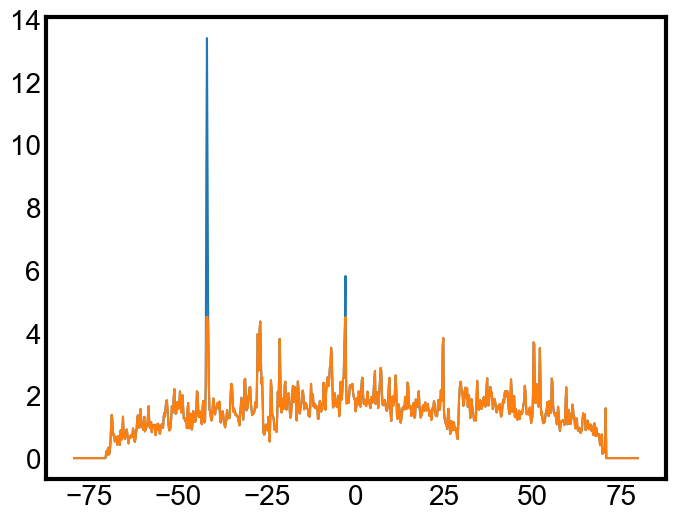

Hermans orientation factor: -0.06424634755229464


In [27]:
I = res1d.intensity
chi = res1d.radial
#herman's orientation factor
# plt.plot(chi, I)
# plt.xlabel("Azimuthal angle (degrees)")
# plt.ylabel("Intensity")
# plt.title("Azimuthal Intensity Profile")
# plt.show()
def hermans_orientation_factor(I, chi):
    """
    Calculate Hermans orientation factor from intensity and azimuthal angle.
    """
    # clip intensities above 4.5
    plt.plot(chi, I)
    I = np.clip(I, None, 4.5)
    plt.plot(chi, I)
    plt.show()
    #integrate the intensity over azimuthal angle
    numerator = np.trapezoid(I * np.cos(chi)**2 * np.sin(chi), chi)
    denominator = np.trapezoid(I * np.sin(chi), chi)
    #calculate the Hermans orientation factor
    cos_term = numerator / denominator
    H = (3 * cos_term - 1) / 2
    
    return H

print("Hermans orientation factor:", hermans_orientation_factor(I, chi))

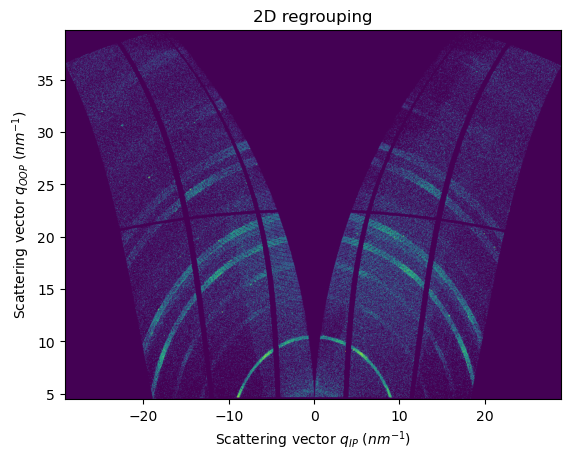

In [ ]:
# fi = load(filename=poni_file, type_="pyFAI.integrator.fiber.FiberIntegrator")
# fi = ai.promote(type_="pyFAI.integrator.fiber.FiberIntegrator")
fi = FiberIntegrator(
    dist=poni.dist,
    poni1=poni.poni1,
    poni2=full_length - poni.poni2,
    wavelength=poni.wavelength,
    rot1=np.pi - poni.rot1,
    rot2=np.pi - poni.rot2,
    rot3=poni.rot3,
    detector=pyFAI.detector_factory("Pilatus1M", {"orientation": 4}),
)
# fi = load(filename=poni_file, type_="pyFAI.integrator.fiber.FiberIntegrator")

# print(fi)
# fi.reset_integrator(incident_angle=alpha_i, tilt_angle=0,  sample_orientation=4)
# print(fi)
# print(fi)
# res = fi.integrate2d_grazing_incidence(image, npt_oop=1024, npt_ip=1024, oop_range=[0,20], ip_range=[0,20], incident_angle=alpha_i, tilt_angle=0, sample_orientation=1) #convert to q_r and q_z
res = fi.integrate2d_grazing_incidence(
    data=image, incident_angle=alpha_i, tilt_angle=0, sample_orientation=6
)


def update_style(ax):
    for img in ax.get_images():
        img.set_cmap("viridis")
        img.set_clim(1, 30)


fig, ax = subplots()
plot2d(result=res, ax=ax)
update_style(ax=ax)
# print(res)